In [2]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import pandas as pd
import time
import sys
import os
from functools import partial

# add the parent directory to the path to import from src
parent_dir = os.path.dirname(os.getcwd())
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# import the algorithm components directly
from src.algorithm import (
    TensorNetwork, 
    evaluate_config, 
    update_edge, 
    estimate_contraction, 
    run_multiple_chains,
    contract_tensor_network
)


In [3]:
# helper functions for geometric statistics on relative errors
# note: when all relative errors are identical (e.g., all = 1.0 due to AIS failure),
#       gstd will correctly return 1.0 (no multiplicative spread). this typically indicates
#       numerical instability from insufficient annealing steps (A too small) or insufficient mixing (C too small)
EPS = 1e-12

def gmean_series(s):
    x = np.clip(s.to_numpy(np.float64), EPS, None)
    # handle edge cases: NaN, inf, or empty
    if len(x) == 0 or np.any(~np.isfinite(x)):
        return np.nan
    log_x = np.log(x)
    if not np.all(np.isfinite(log_x)):
        return np.nan
    return float(np.exp(np.mean(log_x)))

def gvar_series(s):
    x = np.clip(s.to_numpy(np.float64), EPS, None)
    # handle edge cases: NaN, inf, empty, or insufficient samples
    if len(x) < 2 or np.any(~np.isfinite(x)):
        return np.nan
    log_x = np.log(x)
    if not np.all(np.isfinite(log_x)):
        return np.nan
    # return 0.0 if all values are identical (no variance)
    if np.allclose(log_x, log_x[0]):
        return 0.0
    return float(np.var(log_x, ddof=1))

def gstd_series(s):
    """
    Compute true geometric standard deviation: GSD(ε) = exp(Std(log ε))
    Returns ≥ 1, where 1 means no multiplicative spread.
    """
    x = np.clip(s.to_numpy(np.float64), EPS, None)
    # handle edge cases: NaN, inf, empty, or insufficient samples
    if len(x) < 2 or np.any(~np.isfinite(x)):
        return np.nan
    log_x = np.log(x)
    if not np.all(np.isfinite(log_x)):
        return np.nan
    # compute std in log space
    std_log = np.std(log_x, ddof=1)
    # return 1.0 if all values are identical (no variance -> GSD = 1)
    if np.allclose(std_log, 0.0):
        return 1.0
    # true geometric standard deviation: exp(Std(log ε))
    return float(np.exp(std_log))


In [4]:
# A = len(beta) = number of beta ladder steps
# B = n_chains = number of parallel random walks  
# C = iters = number of Glauber updates per chain per beta step

def create_test_tensor_network(network_type="2x2_ring", dim=3, seed=42,
                               eps=1e-6, alpha=0.6, spike_factor=10.0, jitter=0.1):
    """
    network_type options (topology + optional weight model):
      - "2x2_ring", "3x3_grid"                      (old behavior: N(1,0.1))
      - "2x2_ring_uniform1",   "3x3_grid_uniform1"  (uniform around 1, nonnegative)
      - "2x2_ring_diagexp",    "3x3_grid_diagexp"   (exponentially-decaying diagonal)
      - "2x2_ring_spikes",     "3x3_grid_spikes"    (uniform + diagonal spikes)

    dim: index range size for each leg
    alpha: decay rate for diagexp
    spike_factor: multiplicative spike on diagonal entries for spikes
    jitter: half-width of uniform around 1, i.e., U[1-jitter, 1+jitter]
    """
    np.random.seed(seed)

    if "_" in network_type:
        topo, model = network_type.rsplit("_", 1)
    else:
        topo, model = network_type, "gauss"   # old default

    def sample_tensor(shape, rng=np.random):
        k = len(shape)

        if model == "gauss":
            # previous default: N(1, 0.1)
            T = rng.normal(loc=1.0, scale=0.1, size=shape) + eps
            return T

        if model == "uniform1":
            # nonnegative, mildly varying around 1
            T = rng.uniform(1.0 - jitter, 1.0 + jitter, size=shape)
            T = np.maximum(T, eps)
            return T

        if model == "diagexp":
            # all mass on the "full diagonal" with exponential decay
            # build indices grid then mask where all indices are equal
            idx = np.indices(shape)
            mask = np.all(idx == idx[0], axis=0)
            T = np.full(shape, eps, dtype=float)
            # diagonal value ~ exp(-alpha * i) where i is that common index
            # take the first axis as representative
            diag_vals = np.exp(-alpha * np.arange(shape[0]))
            T[mask] = diag_vals[idx[0][mask]]
            return T

        if model == "spikes":
            # base uniform around 1
            T = rng.uniform(1.0 - jitter, 1.0 + jitter, size=shape)
            T = np.maximum(T, eps)
            # add multiplicative spikes on the "full diagonal"
            idx = np.indices(shape)
            mask = np.all(idx == idx[0], axis=0)
            T[mask] *= spike_factor
            return T

        raise ValueError(f"Unknown weight model in network_type: {model}")

    if topo == "2x2_ring":
        G = nx.Graph()
        G.add_edges_from([('A', 'B'), ('B', 'C'), ('C', 'D'), ('D', 'A')])

        tensors = {}
        index_order = {'A': ['i', 'j'], 'B': ['j', 'k'], 'C': ['k', 'l'], 'D': ['l', 'i']}

        for node, inds in index_order.items():
            data = sample_tensor((dim, dim))
            tensors[node] = (data, inds)

        # exact contraction for 2x2 ring (works for any nonnegative values)
        A_, B_, C_, D_ = [tensors[k][0] for k in ['A', 'B', 'C', 'D']]
        Z_true = np.einsum('ij,jk,kl,li->', A_, B_, C_, D_)

    elif topo == "3x3_grid":
        G = nx.Graph()
        tensors = {}
        grid_size = 3
        node_names = {(i, j): f"T{i}{j}" for i in range(grid_size) for j in range(grid_size)}

        def edge_index(i1, j1, i2, j2):
            return f"{i1}{j1}_{i2}{j2}"

        for i in range(grid_size):
            for j in range(grid_size):
                name = node_names[(i, j)]
                neighbors = []
                if j + 1 < grid_size:
                    neighbors.append(edge_index(i, j, i, j+1))
                    G.add_edge(name, node_names[(i, j+1)])
                if i + 1 < grid_size:
                    neighbors.append(edge_index(i, j, i+1, j))
                    G.add_edge(name, node_names[(i+1, j)])
                if j > 0:
                    neighbors.append(edge_index(i, j-1, i, j))
                if i > 0:
                    neighbors.append(edge_index(i-1, j, i, j))

                neighbors = sorted(neighbors)
                shape = (dim,) * len(neighbors)
                data = sample_tensor(shape)
                tensors[name] = (data, neighbors)

        # exact Z is expensive here; leave None to use AIS-only metrics
        Z_true = None

    else:
        raise ValueError(f"Unknown topology in network_type: {network_type}")

    tn = TensorNetwork(G, tensors)
    return tn, Z_true


def run_ais_experiment(tn, A, B, C, seed=None, verbose=False, return_time=True):
    if seed is not None:
        np.random.seed(int(seed))
    # betas = np.linspace(0, 1, A)
    # betas = 1.0 - np.logspace(0, np.log10(1e-6), A)
    betas = np.linspace(0, 1, A)
    betas[0] = 0.0
    betas[-1] = 1.0
    
    start_time = time.time() if return_time else None
    
    # run AIS
    Z_est, Z_std = run_multiple_chains(
        tn, betas, 
        iters=C, 
        burns=min(C//10, C-1),  # 10% burn-in, but at least leave 1 sample
        n_chains=B, 
        verbose=verbose,
    )
    
    end_time = time.time() if return_time else None
    wall_time = (end_time - start_time) if return_time else None
    
    return {
        'Z_est': Z_est,
        'Z_std': Z_std, 
        'time_seconds': wall_time,
        'A': A, 'B': B, 'C': C,
        'N': A * B * C,
        'seed': seed
    }


def compute_relative_error(Z_est, Z_true):
    if Z_true is None:
        return np.nan
    return abs(Z_est - Z_true) / abs(Z_true)


def generate_cost_experiment_data(
    tn,
    N_values,
    A_range,
    B_range,
    Z_true=None,
    n_trials=10,
    seeds=None,
    reseed_network=False,
    network_factory=None,
    verbose=True
):
    """
    If reseed_network is True, you must pass network_factory, a callable (seed -> (tn, Z_true_opt)).
    Example:
        network_factory = partial(create_test_tensor_network, network_type="2x2_ring_spikes", dim=5, spike_factor=12)
    """
    results = []

    # default seeds: backward compatible with old "n_trials" meaning
    if seeds is None:
        seeds = list(range(n_trials))

    total = len(N_values) * len(A_range) * len(B_range) * len(seeds)
    count = 0

    base_tn = tn
    base_Z_true = Z_true

    for N in N_values:
        for A in A_range:
            for B in B_range:
                if N % (A * B) != 0:
                    continue
                C = N // (A * B)
                if C < 1:
                    continue

                for seed in seeds:
                    count += 1
                    if verbose and count % 10 == 0:
                        print(f"[info] progress: {count}/{total} | N={N}, A={A}, B={B}, C={C}, seed={seed}")

                    # choose which TN to use
                    if reseed_network:
                        if network_factory is None:
                            raise ValueError("reseed_network=True requires network_factory.")
                        tn_used, Z_true_seed = network_factory(seed=seed)
                        # prefer per-seed exact if available, else fall back to the base
                        Z_true_used = Z_true_seed if Z_true_seed is not None else base_Z_true
                    else:
                        tn_used = base_tn
                        Z_true_used = base_Z_true

                    out = run_ais_experiment(tn_used, A, B, C, seed=seed, verbose=False)
                    rel_err = compute_relative_error(out['Z_est'], Z_true_used)

                    results.append({
                        'N': N, 'A': A, 'B': B, 'C': C, 'seed': seed,
                        'Z_est': out['Z_est'],
                        'Z_std': out['Z_std'],
                        'rel_error': rel_err,
                        'time_seconds': out['time_seconds']
                    })

    return pd.DataFrame(results)


In [5]:
# heatmap plotting functions

def plot_cost_heatmap(df, N_value, metric='rel_error', aggregation='gmean'):
    data = df[df['N'] == N_value].copy()
    
    if data.empty:
        print(f"[error] no data for N={N_value}")
        return
    
    # aggregate across trials
    if aggregation == 'mean':
        agg_data = data.groupby(['A', 'B'])[metric].mean().reset_index()
    elif aggregation == 'median':
        agg_data = data.groupby(['A', 'B'])[metric].median().reset_index()
    elif aggregation == 'min':
        agg_data = data.groupby(['A', 'B'])[metric].min().reset_index()
    elif aggregation == 'gmean': 
        agg = data.groupby(['A','B'])[metric].apply(gmean_series)
        agg_data = agg.reset_index(name=metric)
    else:
        raise ValueError(f"Unknown aggregation: {aggregation}")

    
    pivot = agg_data.pivot(index='A', columns='B', values=metric)
    C_pivot = data.groupby(['A', 'B'])['C'].first().reset_index().pivot(index='A', columns='B', values='C')
    C_pivot = C_pivot.fillna(0).astype(int)  # fill missing (A,B) combos with 0, then convert to int
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    # main metric heatmap
    sns.heatmap(pivot, annot=True, fmt='.2e' if metric == 'rel_error' else '.2f', 
                cmap='viridis', ax=ax1)
    ax1.set_title(f'{metric.replace("_", " ").title()} ({aggregation})\nN = {N_value}')
    ax1.set_xlabel('B (number of chains)')
    ax1.set_ylabel('A (beta ladder length)')
    
    # C values heatmap  
    sns.heatmap(C_pivot, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title(f'Corresponding C values\n(iterations per chain per beta)')
    ax2.set_xlabel('B (number of chains)')
    ax2.set_ylabel('A (beta ladder length)')
    
    plt.tight_layout()
    plt.show()

def plot_variance_heatmap(df, N_value, metric='rel_error', mode='logvar'):
    data = df[df['N'] == N_value].copy()
    if data.empty:
        print(f"[error] no data for N={N_value}")
        return
    
    if mode == 'logvar':
        agg = data.groupby(['A','B'])[metric].apply(gvar_series).reset_index(name='logvar')
        values = agg.pivot(index='A', columns='B', values='logvar')
        title = 'Variance of log(Rel Error)'
        fmt = '.2e'
        cmap = 'magma'
    elif mode == 'gstd':
        agg = data.groupby(['A','B'])[metric].apply(gstd_series).reset_index(name='gstd')
        values = agg.pivot(index='A', columns='B', values='gstd')
        title = 'Geometric Std Dev of Rel Error'
        fmt = '.2f'
        cmap = 'magma_r'
    else:
        raise ValueError(f"Unknown mode: {mode}")
    
    C_pivot = data.groupby(['A', 'B'])['C'].first().reset_index().pivot(index='A', columns='B', values='C')
    C_pivot = C_pivot.fillna(0).astype(int)  # fill missing (A,B) combos with 0, then convert to int

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    sns.heatmap(values, annot=True, fmt=fmt, cmap=cmap, ax=ax1)
    ax1.set_title(f'{title}\nN = {N_value}')
    ax1.set_xlabel('B (number of chains)')
    ax1.set_ylabel('A (beta ladder length)')

    sns.heatmap(C_pivot, annot=True, fmt='d', cmap='Blues', ax=ax2)
    ax2.set_title('Corresponding C values\n(iterations per chain per beta)')
    ax2.set_xlabel('B (number of chains)')
    ax2.set_ylabel('A (beta ladder length)')
    plt.tight_layout()
    plt.show()


In [6]:
# setup: create tensor network and define parameter ranges
tn, Z_true = create_test_tensor_network("3x3_grid_diagexp", dim=4, seed=42)
if Z_true is None:
    print('[info] computing reference Z_true via exact contraction...')
    Z_true = contract_tensor_network(tn.graph, tn.tensors)
print(f"[info] true contraction Z = {Z_true:.6f}")

N_values = [100000] 

A_range = [20, 50, 100, 200, 500]  # beta ladder lengths
B_range = [5, 10, 20, 25, 50, 100, 200]  # number of chains

print(f"\n[info] parameter ranges:")
print(f"  N = {N_values}")
print(f"  A (beta steps) = {A_range}")
print(f"  B (chains) = {B_range}")

# show what C values we'll get
print(f"\n[info] possible (A,B,C) combinations for N={N_values[0]}:")
valid_combinations = []
for A in A_range:
    for B in B_range:
        if N_values[0] % (A * B) == 0:
            C = N_values[0] // (A * B)
            if C >= 1:
                valid_combinations.append((A, B, C))
                print(f"  A={A:3d}, B={B:3d}, C={C:4d}")

print(f"\n[info] total valid combinations: {len(valid_combinations)}")


[info] computing reference Z_true via exact contraction...
[info] true contraction Z = 1.004537

[info] parameter ranges:
  N = [100000]
  A (beta steps) = [20, 50, 100, 200, 500]
  B (chains) = [5, 10, 20, 25, 50, 100, 200]

[info] possible (A,B,C) combinations for N=100000:
  A= 20, B=  5, C=1000
  A= 20, B= 10, C= 500
  A= 20, B= 20, C= 250
  A= 20, B= 25, C= 200
  A= 20, B= 50, C= 100
  A= 20, B=100, C=  50
  A= 20, B=200, C=  25
  A= 50, B=  5, C= 400
  A= 50, B= 10, C= 200
  A= 50, B= 20, C= 100
  A= 50, B= 25, C=  80
  A= 50, B= 50, C=  40
  A= 50, B=100, C=  20
  A= 50, B=200, C=  10
  A=100, B=  5, C= 200
  A=100, B= 10, C= 100
  A=100, B= 20, C=  50
  A=100, B= 25, C=  40
  A=100, B= 50, C=  20
  A=100, B=100, C=  10
  A=100, B=200, C=   5
  A=200, B=  5, C= 100
  A=200, B= 10, C=  50
  A=200, B= 20, C=  25
  A=200, B= 25, C=  20
  A=200, B= 50, C=  10
  A=200, B=100, C=   5
  A=500, B=  5, C=  40
  A=500, B= 10, C=  20
  A=500, B= 20, C=  10
  A=500, B= 25, C=   8
  A=500, B

In [7]:
# generate experiment data across parameter combinations
seeds = [11, 23, 42, 77, 101]
num_trials = len(seeds)
print(f"[info] running {len(valid_combinations)} combinations x {num_trials} trials = {len(valid_combinations) * num_trials} total experiments")

start_time = time.time()
results_df = generate_cost_experiment_data(
    tn=tn, 
    N_values=N_values, 
    A_range=A_range, 
    B_range=B_range, 
    Z_true=Z_true,
    n_trials=10, 
    seeds=seeds,
    verbose=True
)
end_time = time.time()

print(f"\n[done] experiments completed in {end_time - start_time:.1f} seconds")
print(f"[info] generated {len(results_df)} data points")

print(f"\n[summary] stats:")
print(f"  rel error range: {results_df['rel_error'].min():.2e} to {results_df['rel_error'].max():.2e}")
overall_gm = gmean_series(results_df['rel_error'].dropna())
print(f"  geom mean rel error: {overall_gm:.2e}")
print(f"  time per experiment: {results_df['time_seconds'].mean():.3f} ± {results_df['time_seconds'].std():.3f}s")

results_df.to_csv('cost_optimization_N100k.csv', index=False)
print(f"[done] saved -> cost_optimization_N100k.csv")


[info] running 34 combinations x 5 trials = 170 total experiments
[info] progress: 10/175 | N=100000, A=20, B=10, C=500, seed=101
[info] progress: 20/175 | N=100000, A=20, B=25, C=200, seed=101
[info] progress: 30/175 | N=100000, A=20, B=100, C=50, seed=101
[info] progress: 40/175 | N=100000, A=50, B=5, C=400, seed=101
[info] progress: 50/175 | N=100000, A=50, B=20, C=100, seed=101
[info] progress: 60/175 | N=100000, A=50, B=50, C=40, seed=101
[info] progress: 70/175 | N=100000, A=50, B=200, C=10, seed=101
[info] progress: 80/175 | N=100000, A=100, B=10, C=100, seed=101
[info] progress: 90/175 | N=100000, A=100, B=25, C=40, seed=101
[info] progress: 100/175 | N=100000, A=100, B=100, C=10, seed=101
[info] progress: 110/175 | N=100000, A=200, B=5, C=100, seed=101
[info] progress: 120/175 | N=100000, A=200, B=20, C=25, seed=101
[info] progress: 130/175 | N=100000, A=200, B=50, C=10, seed=101
[info] progress: 140/175 | N=100000, A=500, B=5, C=40, seed=101
[info] progress: 150/175 | N=10000

In [8]:
# diagnostic: check data quality for A=5 (top row of heatmap)
print("[info] checking data for A=5 (top row of heatmap)")
print("=" * 70)
A5_data = results_df[results_df['A'] == 5].copy()
print(f"[info] total rows with A=5: {len(A5_data)}")
print(f"\n[info] relative error statistics for A=5:")
print(A5_data.groupby(['A', 'B'])['rel_error'].describe())
print(f"\n[info] relative error values (raw):")
for (A, B), group in A5_data.groupby(['A', 'B']):
    rel_errors = group['rel_error'].values
    print(f"  A={A}, B={B:3d}: {rel_errors}")
    print(f"    Z_est values: {group['Z_est'].values}")
    print(f"    Z_true: {Z_true:.6f}")
print("=" * 70)


[info] checking data for A=5 (top row of heatmap)
[info] total rows with A=5: 0

[info] relative error statistics for A=5:
Empty DataFrame
Columns: [count, mean, std, min, 25%, 50%, 75%, max]
Index: []

[info] relative error values (raw):


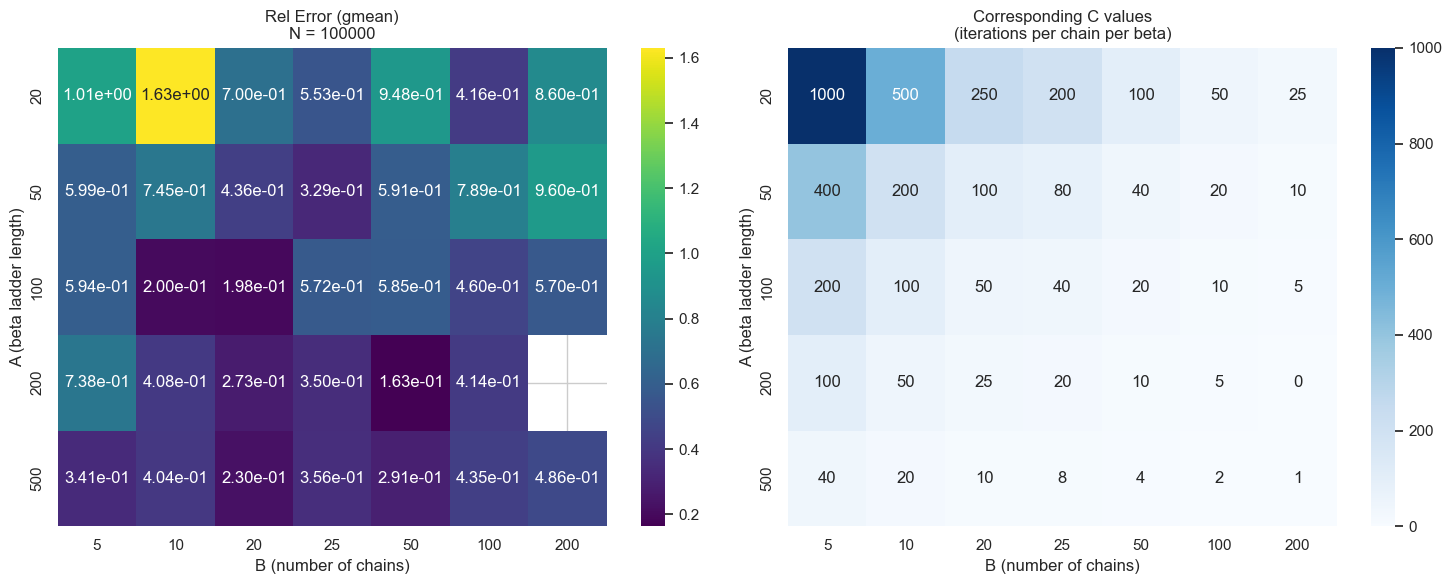

In [9]:
# test 1: geometric mean relative error heatmap
# shows the geometric mean of relative errors across trials for each (A, B) combination
plot_cost_heatmap(results_df, N_value=100000, metric='rel_error', aggregation='gmean')


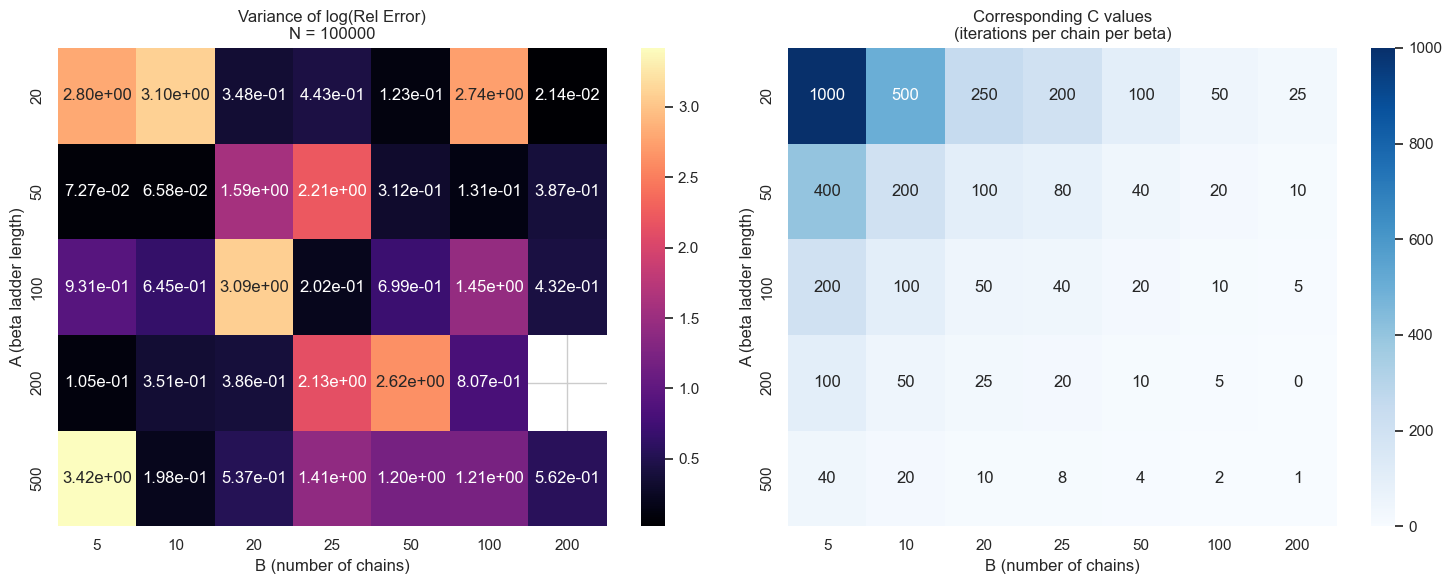

In [10]:
# test 2: variance of log relative error heatmap
# shows the variance in log-space of relative errors across trials for each (A, B) combination
# higher values indicate more variability (worse consistency)
plot_variance_heatmap(results_df, N_value=100000, metric='rel_error', mode='logvar')  # higher is worse


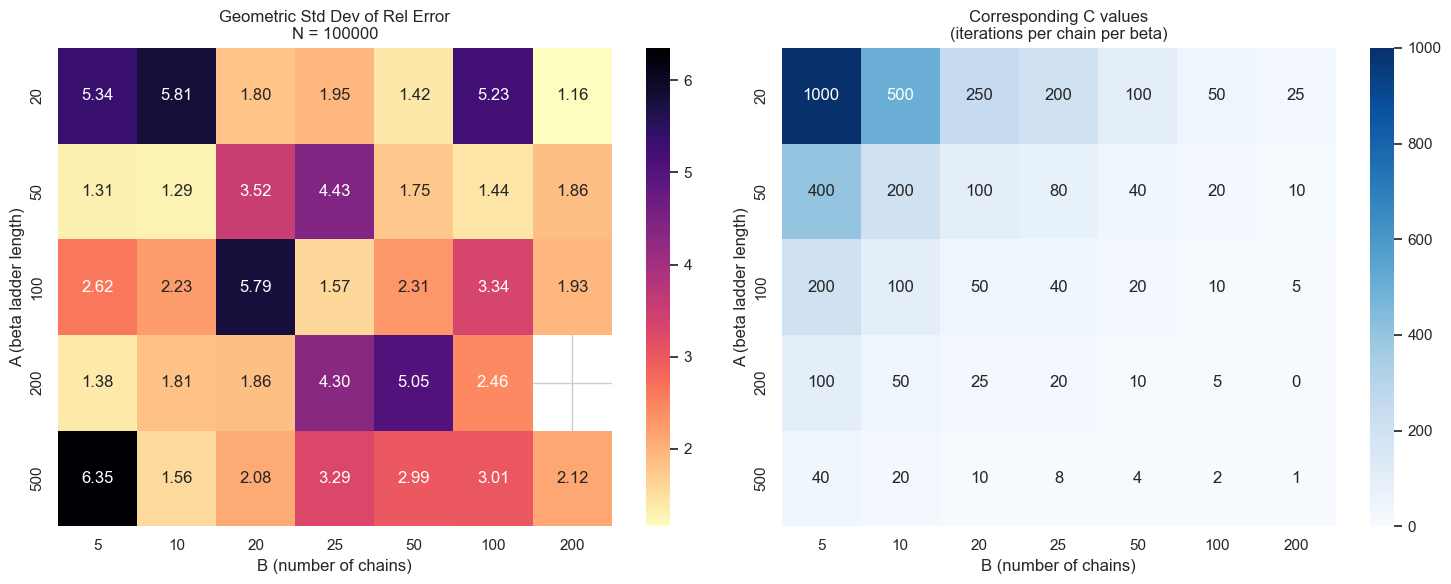

In [11]:
# test 3: geometric standard deviation of relative error heatmap
# shows the geometric standard deviation of relative errors across trials for each (A, B) combination
# values closer to 1.0 indicate more consistent results across trials
plot_variance_heatmap(results_df, N_value=100000, metric='rel_error', mode='gstd')  # closer to 1 is better
